# 1 Likelihood Based Analysis of the 21-cm Power Spectrum


In [9]:
import numpy as np  
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler

In [22]:
# Import simulation data
data_dir = Path("simulations")
files = sorted(data_dir.glob("*.npz"))

# Define test/train/validation split
num_files = len(files)
train_files = files[:int(0.8 * num_files)]
val_files = files[int(0.8 * num_files):int(0.9 * num_files)]
test_files = files[int(0.9 * num_files):]

# Write 
train_simulations = []
test_simulations = []
val_simulations = []

for f in train_files:
    with np.load(f, allow_pickle=True) as d:
        train_simulations.append(dict(d))

for f in val_files:
    with np.load(f, allow_pickle=True) as d:
        val_simulations.append(dict(d))

for f in test_files:
    with np.load(f, allow_pickle=True) as d:
        test_simulations.append(dict(d))

# Unpack
def unpack_simulations(simulations):
    params_list = []
    power_list  = []
    k_list = []
    for sim in simulations:
        astro = sim['astro_params'].item()
        cosmo = sim['cosmo_params'].item()
        params_list.append([astro['L40_xray'], astro['fesc10'],
                            astro['epsstar'],  cosmo['h_fid']])
        power_list.append(sim['power'])
        k_list.append(sim['k'])
    return np.array(params_list), np.array(power_list), np.array(k_list)

raw_params_train, power_train, k_train = unpack_simulations(train_simulations)
raw_params_val,   power_val,   k_val   = unpack_simulations(val_simulations)
raw_params_test,  power_test,  k_test  = unpack_simulations(test_simulations)




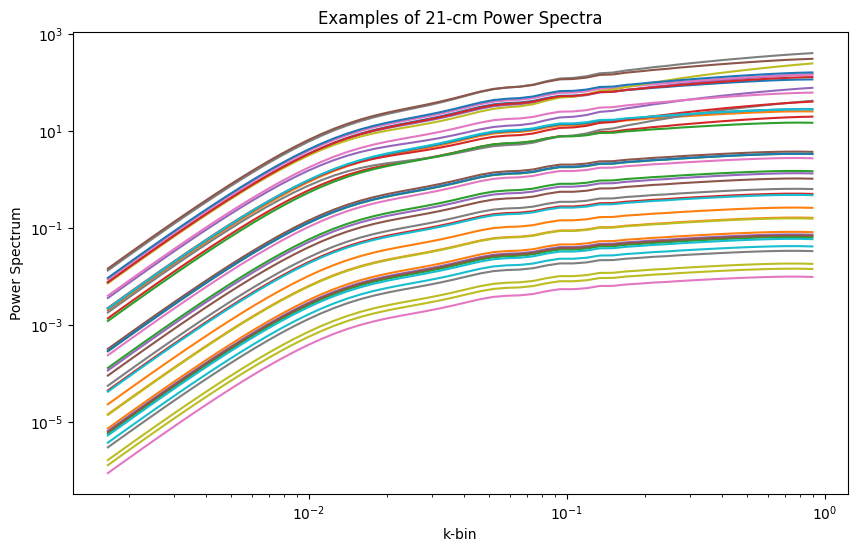

In [27]:
# Plot the power spectra examples
plt.figure(figsize=(10, 6))
for i in  range(0, 8000, 200):
    plt.loglog(k_train[i], power_train[i], label=f'Sim {i+1}')
plt.xlabel('k-bin')
plt.ylabel('Power Spectrum')
plt.title('Examples of 21-cm Power Spectra')
# plt.legend()
plt.show()

- We must normalise the training parameters as they can have different scales with respect to one another. We don't want to bias the trained NN based on the various input scales so we can scale them using a StandardScaler, which brings the mean to 0 and variance to 1.
- Each power spectrum mode has a different scale. For PCA, we want to find meaningful variations, not just the largest magnitude variations, which can be a result of different component scales. A component can have little relative variance in its axis but a huge absolute variance because of scale. We might consider scaling these to but from plotting the data, we know the spectra have consistent dynamic ranges: the shape changes, not the magnitude.
- For the 21-cm power spectra here the raw values work fine, so we pass them directly to PCA.

In [28]:
# Normalise (Scale) datasets
params_scaler = StandardScaler().fit(raw_params_train)

# Apply the same transformation to all datasets
params_train = params_scaler.transform(raw_params_train)
params_val   = params_scaler.transform(raw_params_val)
params_test  = params_scaler.transform(raw_params_test)

- Now we apply PCA on this data

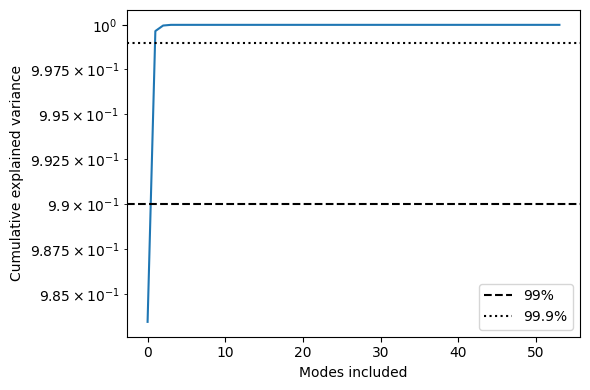

In [ ]:
# Compute the covairance matrix of the power spectra
power_cov = np.cov(power_train, rowvar=False)
evals, evecs = np.linalg.eig(power_cov) # evecs are columns


# Sort from largest to smallest eigenvalues
args = np.argsort(evals)[::-1] # Decreasing size has to flip
evals = np.real(evals[args])
evecs = evecs[:, args]

# Look at explained variance plot
exp_var = evals / np.sum(evals)
cum_exp_var = np.cumsum(exp_var)


# Plot the explained variance
plt.figure(figsize=(6,4))
plt.yscale('log')
plt.plot(cum_exp_var)
plt.axhline(0.99, ls='--', c='k', label='99%')
plt.axhline(0.999, ls=':', c='k', label='99.9%')
plt.xlabel("Modes included")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
thresholds = [0.99, 0.999, 0.9999]
for threshold in thresholds:
    n = np.searchsorted(cum_exp_var, threshold) + 1
    print(f"{100 * threshold:.1f}% threshold explained by first {n} components")

99.0% threshold explained by first 2 components
99.9% threshold explained by first 2 components
100.0% threshold explained by first 3 components


- This tells us that the first three eigenvectors are all we need to describe the entire variance of this data. It will be valid to compress the training data down using just the first three eigenvectors. 
- However, the explained variance does not correspond directly to emulator accuracy. There are a few more factors to consider:
    - The emulated likelihood may depend on some rare features which only appear in the extremes of some parameter. Because the feature is rare, this leaves a very low variance footprint in the PCA.
    - The emulated likelihood may depend on some small scale feature which looks very small in absolute variance terms.
    - The training set may not be completely representative. Some features appearing in the validation set might not appear here.
- It would not cost too much more to perform the analysis with a few more components for safety.

In [72]:
n_comp = 6

# Project the spectra onto the top n_comp components
projected_coeffs = np.dot(power_train, evecs[:,:n_comp]) # bc evecs are columns we take all rows

# Check reconstructed spectra
def check_reconstructed_spectra(idx=0, plot = False):
    reconstructed = np.dot(projected_coeffs[idx], evecs[:, :n_comp].T)
    
    frac_residual = 100 * np.abs(power_train[idx] - reconstructed) / np.abs(power_train[idx])

    if plot == True:
        fig, ax = plt.subplots(1, 3, figsize=(10, 3))
        
        for i in range(n_comp):
            ax[0].semilogx(k_train[i], projected_coeffs[idx, i] * evecs[:, i], label=f'E-vec {i+1}')
        ax[0].set_xlabel(r'$k$  [Mpc$^{-1}$]')
        ax[0].set_ylabel('Contribution')
        ax[0].set_title('PCA components')
        ax[0].legend(fontsize=7)
        ax[1].loglog(k_train[0], power_train[idx],   label='Original')
        ax[1].loglog(k_train[0], reconstructed, label=f'PCA with {n_comp} components)', ls='--')
        ax[1].set_xlabel(r'$k$  [Mpc$^{-1}$]')
        ax[1].set_ylabel(r'$\Delta^2(k)$  [mK$^2$]')
        ax[1].set_title('Reconstructed spectrum')
        ax[1].legend()
        
        ax[2].semilogx(k_train[0], frac_residual)
        ax[2].set_xlabel(r'$k$  [Mpc$^{-1}$]')
        ax[2].set_ylabel('Fractional residual (%)')
        ax[2].set_title('Residual')
        
        plt.tight_layout()
        plt.show()
    mean_frac_residual = frac_residual.mean()
    return mean_frac_residual

c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


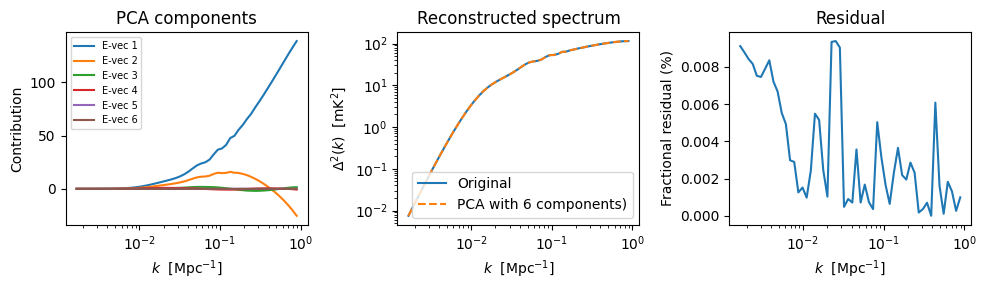

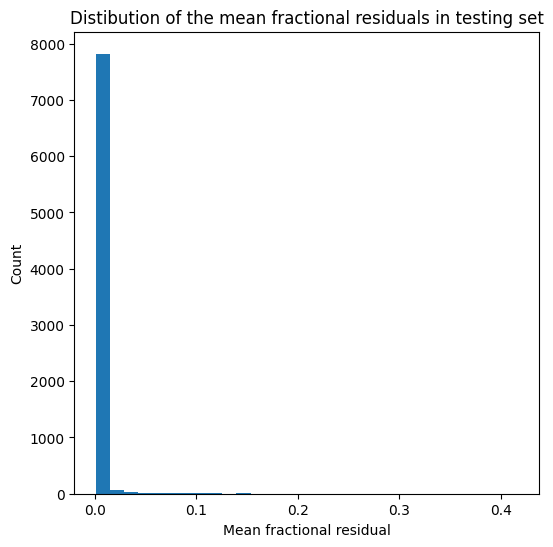

In [75]:
_ = check_reconstructed_spectra(plot = True)
frac_residuals= []

for j in range(0,len(projected_coeffs)):
    frac_residual = check_reconstructed_spectra(idx=j)
    frac_residuals.append(frac_residual)

# Plot histogram of fractional residuals
plt.figure(figsize=(6,6))
plt.hist(frac_residuals, bins= 30)
plt.title("Distibution of the mean fractional residuals in testing set")
plt.xlabel("Mean fractional residual")
plt.ylabel("Count")
plt.show()

In [ ]:
dataset1 = np.load(files[0], allow_pickle=True)
dataset1.files
k = dataset1["k"]
power = dataset1["power"]
astro_params = dataset1["astro_params"]
cosmo_params = dataset1["cosmo_params"]
redshifts = dataset1["redshfit"]
code = dataset1["code"]
code_version = dataset1["code_version"]

for name, value in {
    "k": k,
    "power": power,
    "astro_params": astro_params,
    "cosmo_params": cosmo_params,
    "redshifts": redshifts,
    "code": code,
    "code_version": code_version,
}.items():
    print(f"{name}: {np.shape(value)}")

# print(k)
print(power)
print(np.log(min(power)), np.log(max(power)))
# print(astro_params)
# print(cosmo_params)
# print(redshifts)
# print(code)
# print(code_version)

k: (54,)
power: (54,)
astro_params: ()
cosmo_params: ()
redshifts: ()
code: ()
code_version: ()
[7.47685668e-03 1.17543845e-02 1.84238133e-02 2.87766302e-02
 4.47646190e-02 6.93055195e-02 1.06708847e-01 1.63245637e-01
 2.47878651e-01 3.73112822e-01 5.55905140e-01 8.18373566e-01
 1.18797717e+00 1.69641376e+00 2.37663902e+00 3.25690954e+00
 4.35249707e+00 5.65582583e+00 7.13087339e+00 8.71596303e+00
 1.03440688e+01 1.19720621e+01 1.36169846e+01 1.53657351e+01
 1.73573602e+01 1.97819180e+01 2.28448366e+01 2.66964759e+01
 3.11004660e+01 3.50089825e+01 3.71703915e+01 3.82915299e+01
 4.12093427e+01 4.74106189e+01 5.26737507e+01 5.31096109e+01
 5.61649336e+01 6.30732838e+01 6.40220110e+01 6.90476713e+01
 7.24870554e+01 7.67418995e+01 7.99308894e+01 8.42847893e+01
 8.80104033e+01 9.18137867e+01 9.56606479e+01 9.93856162e+01
 1.02964900e+02 1.06345587e+02 1.09440159e+02 1.12026565e+02
 1.13814238e+02 1.14498132e+02]
-4.895942805268216 4.740558504202362
